# Лабораторная работа 1. Линейная регрессия и факторный анализ

# Выполнил студент Зенцов Вадим, АВТ-313

# Введение.

## Описание работы
Цель работы: изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.

## Постановка задачи:

1. Провести обучение модели линейной регрессии на датасете с Kaggle:

2. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).

3. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной.

4. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).

5. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).

6. Построить регрессионные модели (линейная, лассо и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).

7. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA). Перед проведением PCA провести стандартизацию данных.

8. Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

## Содержание отчета:

1. Введение. Краткое описание целей и задач работы.

2. Описание датасета. Опишите рассматриваемый датасет, покажите графики распределения признаков и корреляционную матрицу.

3. Подготовка данных. Подробно изложите процедуры предобработки данных (нормализация, заполнение пропусков, разделение выборки на train/test).

4. Ход работы. Опишите подробно выбранные варианты реализации регрессии до устранения мультиколлинеарности. Рассчитайте основные метрики (RMSE, R², MAPE) и представьте их графически или таблично. Покажите устранение мультиколлинеарности с помощью PCA (приведите график каменистой осыпи), затем заново постройте модели регрессии и сравните полученные значения метрик с теми, которые получились до этого.

5. Заключение. Сделайте вывод о результатах работы.

6. Список источников. Приведите использованную литературу и ссылки на ресурсы.

7. Приложение. Включите полный листинг программного кода. [1]

# Описание датасета

## Содержание датасета

Датасет представляет из себя предсказание цены на машину на основе следующих признаков [2]:
- название (категориальный);
- год выпуска (количественный дискретный);
- пробег автомобиля в километрах (количественный дискретный);
- тип топлива (категориальный), продавец (категориальный);
- тип коробки передач (категориальный бинарный);
- количество владельцев (категориальный порядковый);
- расход топлива километр на литр (количественный вещественный);
- объем двигателя в кубических сантиметрах (количественный вещественный);
- максимальная мощность двигателя в лошадиных силах (количественный вещественный);
- количество сидений (количественный дискретный).

## Первичный анализ

Получить первые 10 записей из таблицы:


In [99]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/cardekho.csv')
df.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,5.0
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,Manual,First Owner,17.30,1061.0,57.5,5.0
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.10,796.0,37,4.0
8,Toyota Etios VXD,2011,350000,90000,Diesel,Individual,Manual,First Owner,23.59,1364.0,67.1,5.0
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Individual,Manual,First Owner,20.00,1399.0,68.1,5.0


Если вышла ошибка, что датасет не найден, необходимо добавить приложенный к данному блокноту файл cardekho.csv в текущую сессию.

Размер датасета:

In [100]:
print("Строк:", df.shape[0])
print("Столбцов:", df.shape[1])

Строк: 8128
Столбцов: 12


Типы и общая информация:

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


Количество пропусков:

In [102]:
import pandas as pd

missing = pd.DataFrame({
    'Пропусков (шт.)': df.isna().sum(),
    'Доля (%)': (df.isna().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Пропусков (шт.)'] > 0].sort_values('Пропусков (шт.)', ascending=False)
print(missing)

                    Пропусков (шт.)  Доля (%)
mileage(km/ltr/kg)              221      2.72
engine                          221      2.72
seats                           221      2.72
max_power                       215      2.65


Дубликаты:

In [103]:
print("Дубликатов:", df.duplicated().sum())

Дубликатов: 1202


Описательная статистика:

In [104]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


Корреляция:

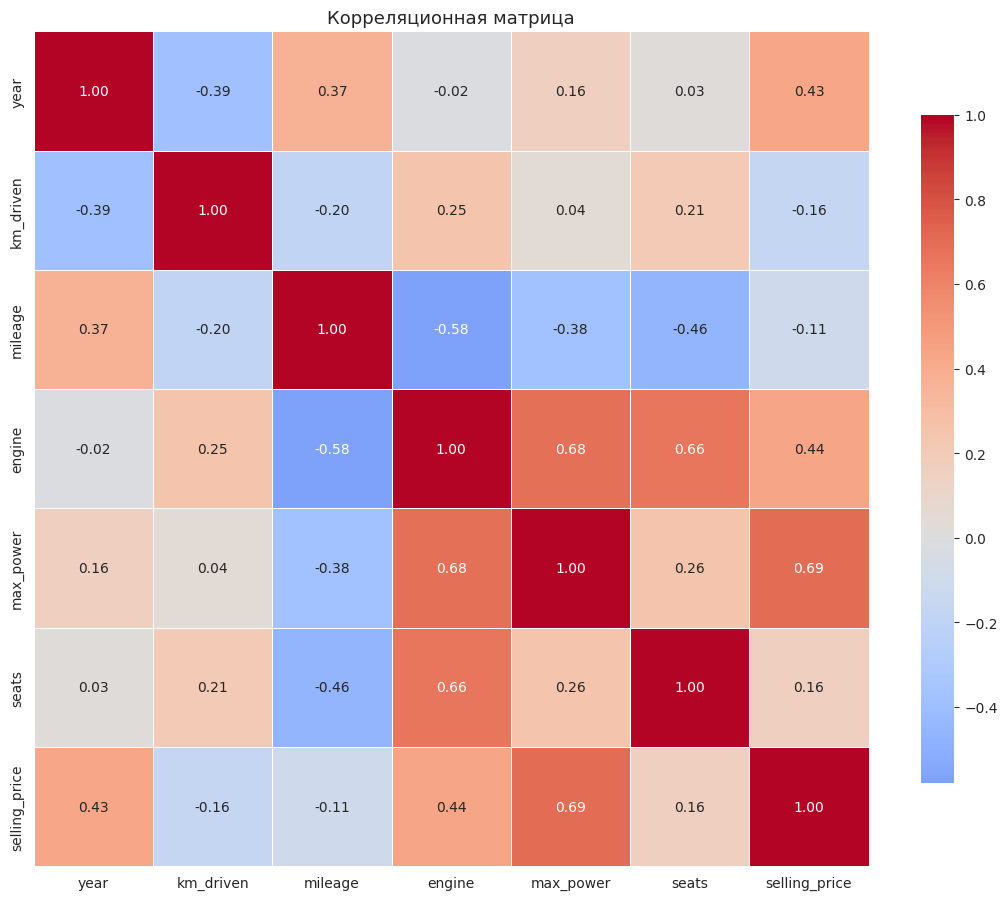

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/cardekho.csv')

df = df.rename(columns={'mileage(km/ltr/kg)': 'mileage'})

df['mileage']   = df['mileage'].astype(str).str.extract(r'([\d.]+)').astype(float)
df['engine']    = df['engine'].astype(str).str.extract(r'(\d+)').astype(float)
df['max_power'] = df['max_power'].astype(str).str.extract(r'([\d.]+)').astype(float)

df = df.dropna()
df = df.drop_duplicates()

num_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
target = 'selling_price'

corr = df[num_cols + [target]].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

График распределения признаков:

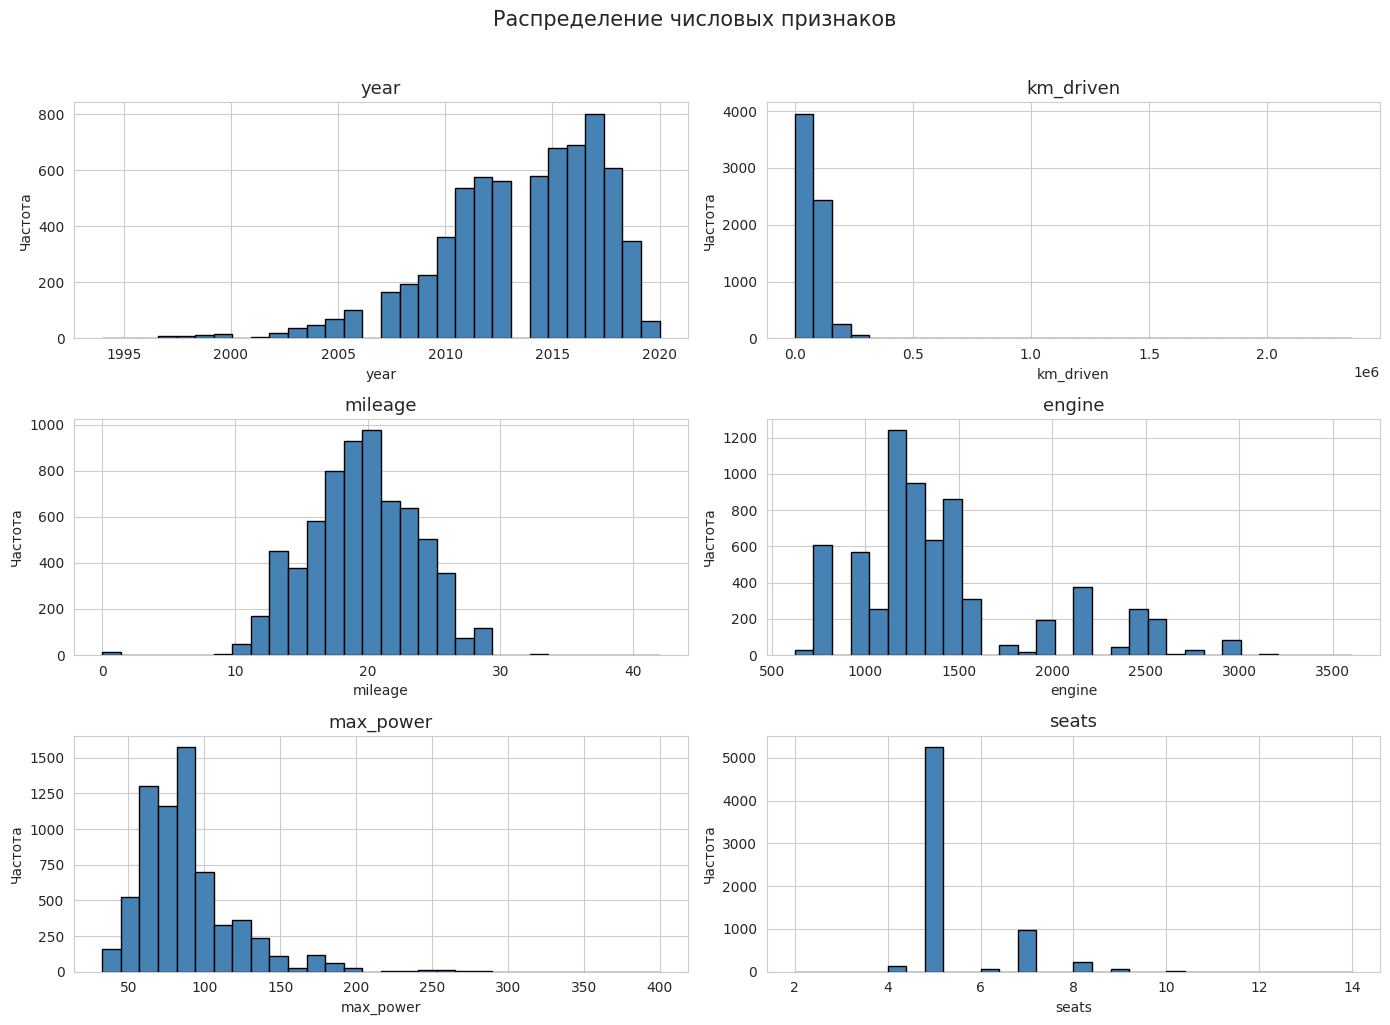

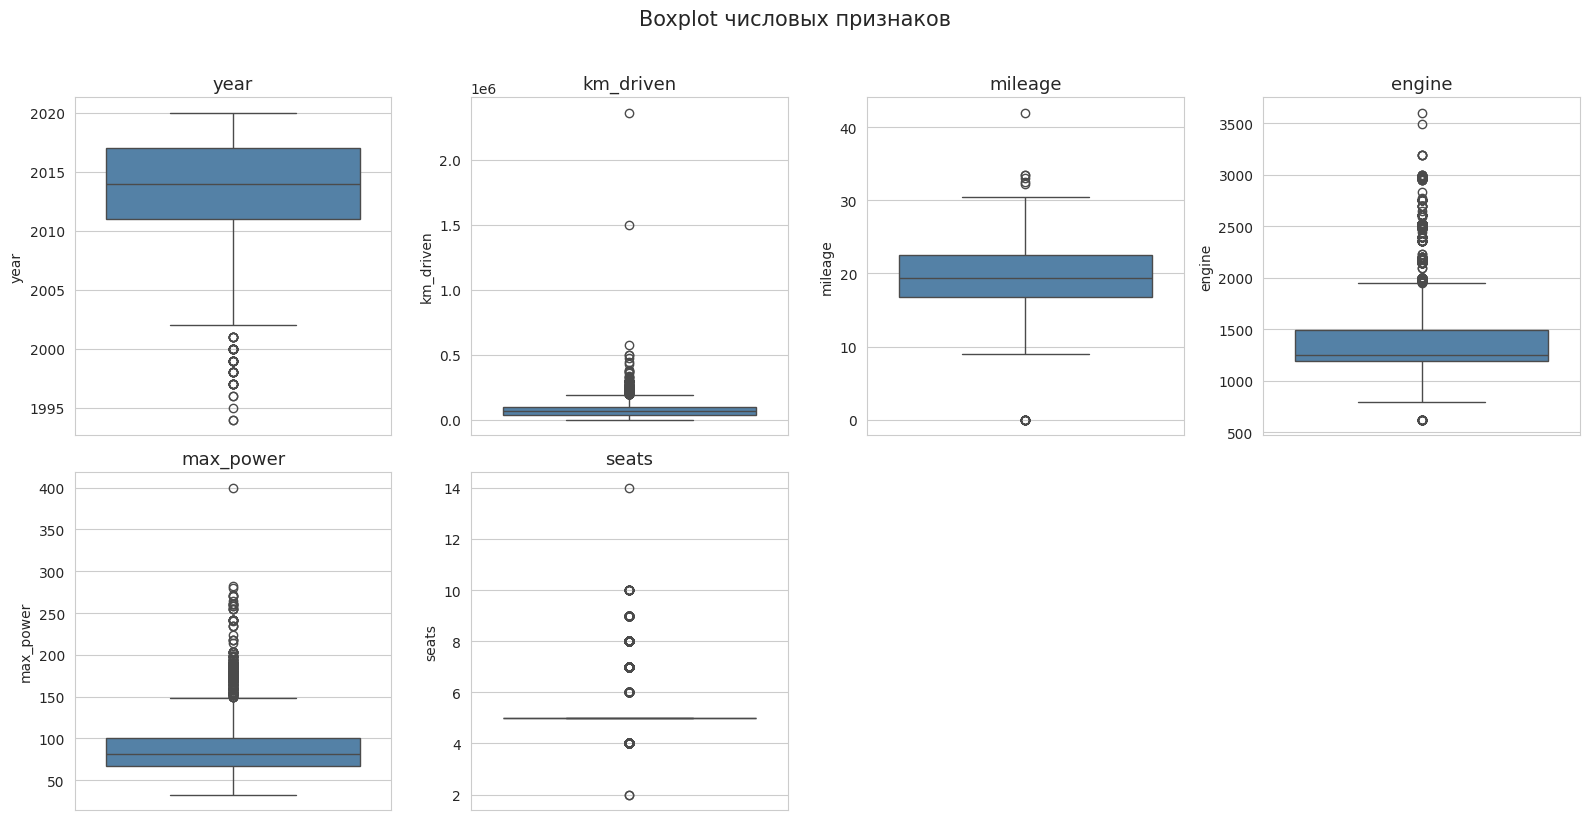

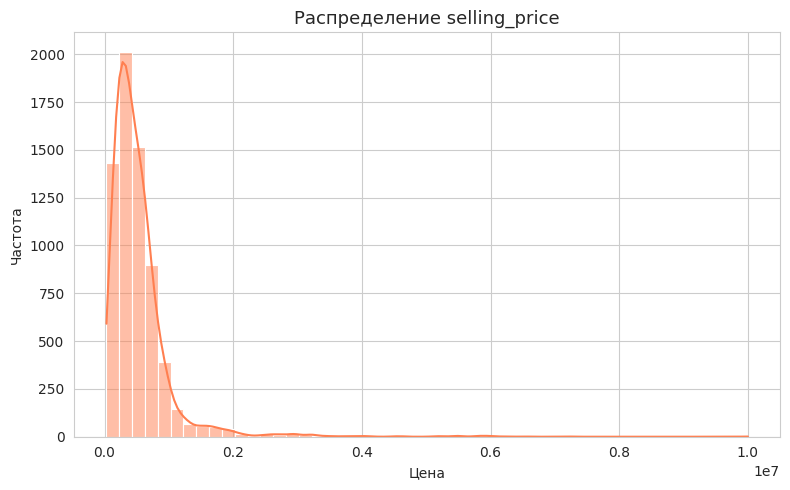

count    6.717000e+03
mean     5.263860e+05
std      5.235504e+05
min      2.999900e+04
25%      2.500000e+05
50%      4.200000e+05
75%      6.500000e+05
max      1.000000e+07
Name: selling_price, dtype: float64
Асимметрия: 5.57


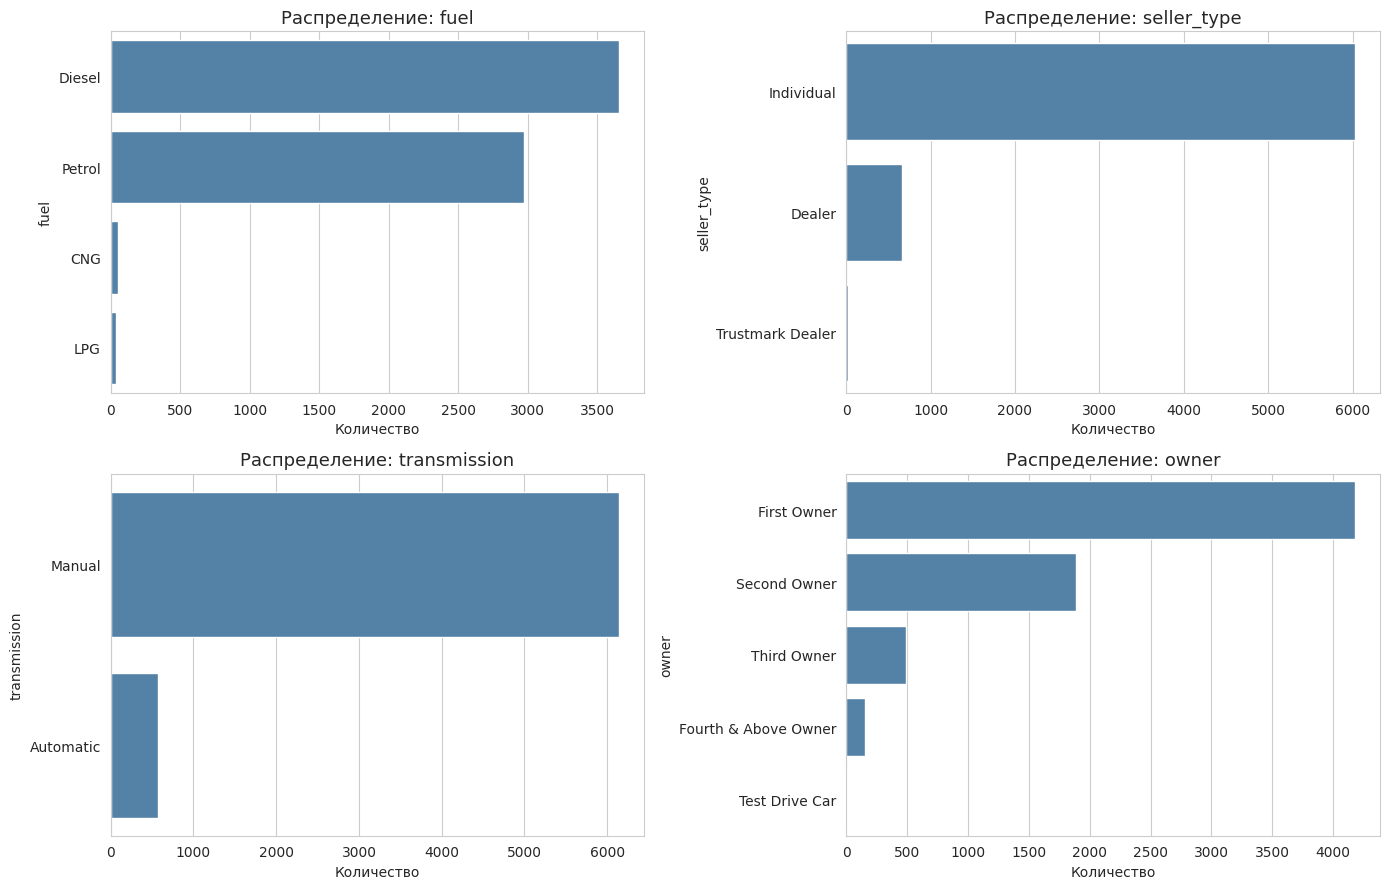

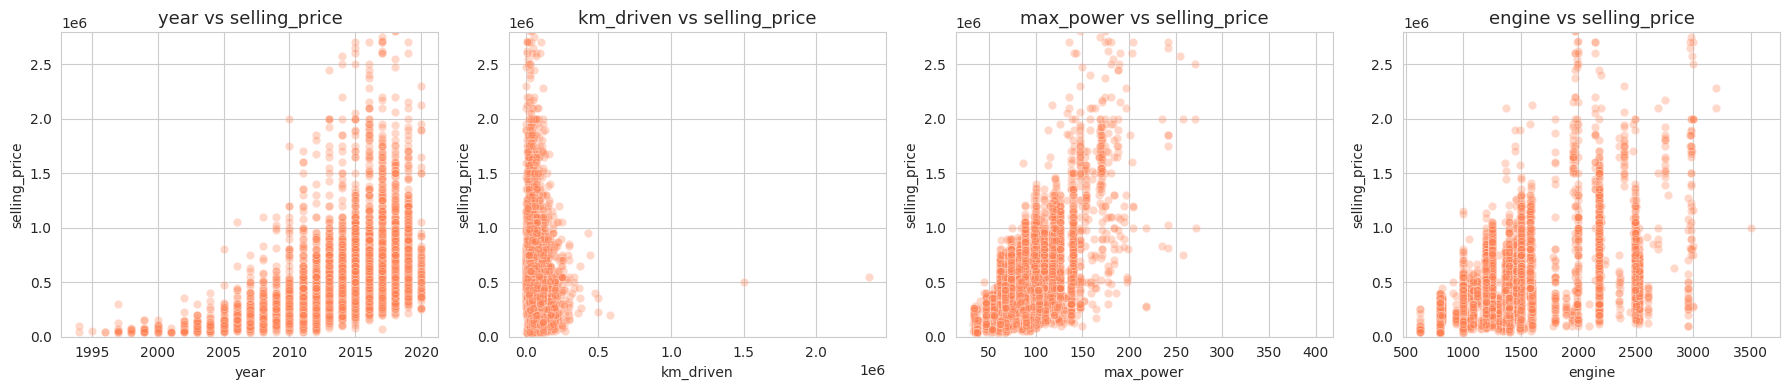

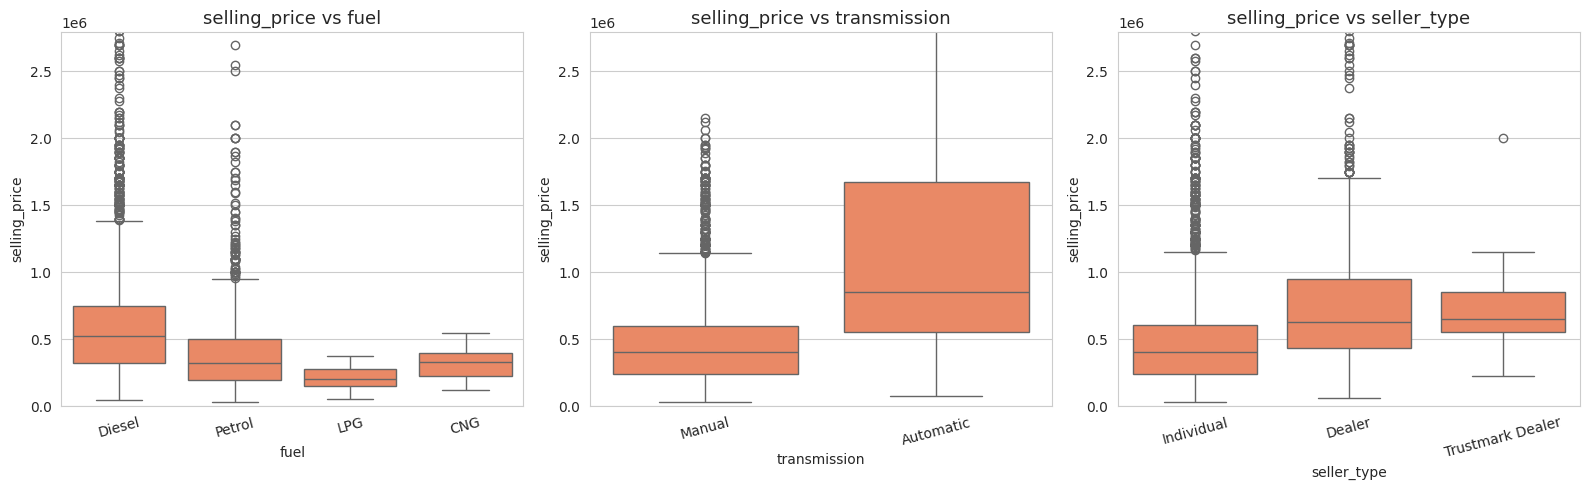

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13

df = pd.read_csv('/content/cardekho.csv')

df = df.rename(columns={'mileage(km/ltr/kg)': 'mileage'})

df['mileage']   = df['mileage'].astype(str).str.extract(r'([\d.]+)').astype(float)
df['engine']    = df['engine'].astype(str).str.extract(r'(\d+)').astype(float)
df['max_power'] = df['max_power'].astype(str).str.extract(r'([\d.]+)').astype(float)

df = df.dropna()
df = df.drop_duplicates()

num_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
target = 'selling_price'

axes = df[num_cols].hist(figsize=(14, 10), bins=30,
                         edgecolor='black', color='steelblue')

for ax, col in zip(axes.flatten(), num_cols):
    ax.set_xlabel(col)
    ax.set_ylabel("Частота")
    ax.set_title(col)

plt.suptitle("Распределение числовых признаков", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle("Boxplot числовых признаков", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=50, kde=True, color='coral')
plt.title(f"Распределение {target}")
plt.xlabel("Цена")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()

print(df[target].describe())
print("Асимметрия:", df[target].skew().round(2))

cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], color='steelblue')
    axes[i].set_title(f"Распределение: {col}")
    axes[i].set_xlabel("Количество")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 4, figsize=(18, 4))
key_features = ['year','km_driven', 'max_power', 'engine']

for i, col in enumerate(key_features):
    sns.scatterplot(data=df, x=col, y=target, alpha=0.3, ax=axes[i], color='coral')
    axes[i].set_title(f"{col} vs {target}")
    axes[i].set_ylim(0, df[target].quantile(0.99))

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(['fuel', 'transmission', 'seller_type']):
    sns.boxplot(data=df, x=col, y=target, ax=axes[i], color='coral')
    axes[i].set_title(f"{target} vs {col}")
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, df[target].quantile(0.99))
plt.tight_layout()
plt.show()

Расчёт VIF-коэффициента:

In [107]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

num_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
X = df[num_cols].dropna()

vif_data = pd.DataFrame()
vif_data["Признак"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

vif_data.style.background_gradient(cmap='coolwarm').format({"VIF": "{:.2f}"})

,Признак,VIF
0,year,1.63
1,km_driven,1.31
2,mileage,2.00
3,engine,4.04
4,max_power,2.38
5,seats,2.16


Согласно результатам оценки по VIF-коэффициенту, мультиколлинеарность присутствует, так как значение одного из коэффициентов выше 3.

# Подготовка данных.


## Получение исходных данных.

In [108]:
df = pd.read_csv('/content/cardekho.csv')

df = df.rename(columns={'mileage(km/ltr/kg)': 'mileage'})

df['mileage']   = df['mileage'].astype(str).str.extract(r'([\d.]+)').astype(float)
df['engine']    = df['engine'].astype(str).str.extract(r'(\d+)').astype(float)
df['max_power'] = df['max_power'].astype(str).str.extract(r'([\d.]+)').astype(float)

## Обработка категориальных переменных, пропусков и дубликатов.

Удаляем столбцы с категориальными переменными:

In [109]:
df = df.drop(columns=['name', 'fuel',	'seller_type',	'transmission',	'owner', 'seats'])

Дубликаты и пустые строки в таблице удалены, так как пустые значения занимают менее 5% от общего количества данных и не могут сильно повлиять на результат.

In [110]:
df = df.dropna().drop_duplicates().reset_index(drop=True)

## Подготовка данных для модели.

Разделение на X и y:

In [111]:
target = 'selling_price'
X = df.drop(columns=[target])
y = df[target]


Разделение на train/test:

In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (4666, 5)
Test:  (2001, 5)


Стандартизация:

In [113]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_features = ['km_driven', 'mileage', 'engine', 'max_power']

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features]  = scaler.transform(X_test[num_features])

# Ход работы.

## Линейная регрессия.

Алгоритм предсказания на модели линейной регрессии:

1. Создание модели.

2. Кросс-валидация модели с оценкой по метрике R^2.

3. Обучение модели на train.

4. Предсказывание значений цены на тестовых данных.

5. Вытаскивание метрик.

In [114]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

model_lr = LinearRegression()

cv_r2 = cross_val_score(model_lr, X_train_scaled, y_train,
                        cv=5, scoring='r2')

print("Кросс-валидация Linear Regression (R²):")
print(f"  Фолды:   {cv_r2.round(4)}")
print(f"  Среднее: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

model_lr.fit(X_train_scaled, y_train)

y_pred = model_lr.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("\nМетрики на тесте:")
print(f"  RMSE: {rmse:,.0f} руб.   (в среднем модель ошибается на эту сумму)")
print(f"  R²:   {r2:.4f}            (модель объясняет {r2*100:.1f}% вариации цены)")
print(f"  MAPE: {mape*100:.2f}%          (средняя ошибка в процентах)")


Кросс-валидация Linear Regression (R²):
  Фолды:   [0.5936 0.5884 0.5281 0.6244 0.5818]
  Среднее: 0.5832 ± 0.0312

Метрики на тесте:
  RMSE: 323,085 руб.   (в среднем модель ошибается на эту сумму)
  R²:   0.5750            (модель объясняет 57.5% вариации цены)
  MAPE: 62.05%          (средняя ошибка в процентах)


С логарифмизацией данных.

In [115]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

model_lr_log = LinearRegression()

cv_r2_log = cross_val_score(model_lr_log, X_train_scaled, y_train_log,
                            cv=5, scoring='r2')

print("Кросс-валидация Linear Regression с логарифмом (R²):")
print(f"  Фолды:   {cv_r2_log.round(4)}")
print(f"  Среднее: {cv_r2_log.mean():.4f} ± {cv_r2_log.std():.4f}")

model_lr_log.fit(X_train_scaled, y_train_log)

y_pred_log = model_lr_log.predict(X_test_scaled)

y_pred_log_orig = np.expm1(y_pred_log)
y_test_orig     = np.expm1(y_test_log)

rmse_log = np.sqrt(mean_squared_error(y_test_orig, y_pred_log_orig))
r2_log   = r2_score(y_test_orig, y_pred_log_orig)
mape_log = mean_absolute_percentage_error(y_test_orig, y_pred_log_orig)

print("\nМетрики на тесте (в исходной шкале, рубли):")
print(f"  RMSE: {rmse_log:,.0f} руб.")
print(f"  R²:   {r2_log:.4f}  (объяснено {r2_log*100:.1f}%)")
print(f"  MAPE: {mape_log*100:.2f}%")

Кросс-валидация Linear Regression с логарифмом (R²):
  Фолды:   [0.8327 0.8243 0.8285 0.8419 0.845 ]
  Среднее: 0.8345 ± 0.0079

Метрики на тесте (в исходной шкале, рубли):
  RMSE: 255,561 руб.
  R²:   0.7341  (объяснено 73.4%)
  MAPE: 25.59%


После применения логарифмизации целевого признака показатели увеличились: RMSE на 30%, R^2 на 31,6%, MAPE на 35%. В дальнейшем логарифмизация целевого признака будет применяться во всех моделях для получения точных данных.

## Lasso-регрессия

Алгоритм обучения модели Lasso-регрессии:

1. Создание логарифмического массива регулирующих коэффициентов.

2. Кросс-валидация модели для подбора оптимального регулирующего коэффициента.

3. Создание модели Lasso-регрессии с подобранным ранее коэффициентом.

4. Кросс-валидация созданной модели на train data.

5. Обучение модели.

6. Предсказание цены на test data.

7. Вытаскивание метрик.

In [116]:
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import pandas as pd

alphas = np.logspace(-4, 1, 50)
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train_log)

print(f"Оптимальный alpha: {lasso_cv.alpha_:.6f}")
print(f"Признаков с ненулевым коэффициентом: "
      f"{(lasso_cv.coef_ != 0).sum()} из {len(lasso_cv.coef_)}")

model_lasso = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)

cv_r2_lasso = cross_val_score(model_lasso, X_train_scaled, y_train_log,
                              cv=5, scoring='r2')
print(f"\nCV R² Lasso: {cv_r2_lasso.mean():.4f} ± {cv_r2_lasso.std():.4f}")

model_lasso.fit(X_train_scaled, y_train_log)

y_pred_lasso = np.expm1(model_lasso.predict(X_test_scaled))
y_test_orig  = np.expm1(y_test_log)

rmse_l = np.sqrt(mean_squared_error(y_test_orig, y_pred_lasso))
r2_l   = r2_score(y_test_orig, y_pred_lasso)
mape_l = mean_absolute_percentage_error(y_test_orig, y_pred_lasso)

print(f"\nМетрики Lasso на тесте:")
print(f"  RMSE: {rmse_l:,.0f} руб.")
print(f"  R²:   {r2_l:.4f}")
print(f"  MAPE: {mape_l*100:.2f}%")

Оптимальный alpha: 0.005429
Признаков с ненулевым коэффициентом: 4 из 5

CV R² Lasso: 0.8347 ± 0.0080

Метрики Lasso на тесте:
  RMSE: 255,109 руб.
  R²:   0.7350
  MAPE: 25.62%


Обнуленные коэффициенты:

In [117]:
import pandas as pd

coef_df = pd.DataFrame({
    'Признак': X_train_scaled.columns,
    'Коэффициент': model_lasso.coef_
}).sort_values('Коэффициент', key=abs, ascending=False)

print(coef_df.to_string(index=False))

  Признак  Коэффициент
max_power     0.316834
   engine     0.185646
     year     0.118922
  mileage     0.070832
km_driven    -0.000000


## Ridge-регрессия.

1. Создание логарифмического массива с регулирующими коэффициентами.

2. Подбор оптимального регулирующего коэффициента через кросс-валидацию по train data.

3. Создание модели Ridge-регрессии с подобранным регулирующим коэффициентом.

4. Кросс-валидация модели на train data.

5. Предсказание значений цены на основе признаков.

6. Вытаскивание метрик.

In [118]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import pandas as pd

alphas = np.logspace(-4, 2, 50)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train_log)

print(f"Оптимальный alpha: {ridge_cv.alpha_:.6f}")

model_ridge = Ridge(alpha=ridge_cv.alpha_)

cv_r2_ridge = cross_val_score(model_ridge, X_train_scaled, y_train_log,
                              cv=5, scoring='r2')
print(f"\nCV R² Ridge: {cv_r2_ridge.mean():.4f} ± {cv_r2_ridge.std():.4f}")

model_ridge.fit(X_train_scaled, y_train_log)

y_pred_ridge = np.expm1(model_ridge.predict(X_test_scaled))
y_test_orig  = np.expm1(y_test_log)

rmse_r = np.sqrt(mean_squared_error(y_test_orig, y_pred_ridge))
r2_r   = r2_score(y_test_orig, y_pred_ridge)
mape_r = mean_absolute_percentage_error(y_test_orig, y_pred_ridge)

print(f"\nМетрики Ridge на тесте:")
print(f"  RMSE: {rmse_r:,.0f} руб.")
print(f"  R²:   {r2_r:.4f}")
print(f"  MAPE: {mape_r*100:.2f}%")

Оптимальный alpha: 42.919343

CV R² Ridge: 0.8345 ± 0.0080

Метрики Ridge на тесте:
  RMSE: 255,628 руб.
  R²:   0.7340
  MAPE: 25.58%


## Создание сводной таблицы.

In [119]:
import pandas as pd

comparison = pd.DataFrame({
    'Модель': ['Linear', 'Lasso', 'Ridge'],
    'CV R² (train)': [cv_r2_log.mean(), cv_r2_lasso.mean(), cv_r2_ridge.mean()],
    'RMSE (test)':   [rmse_log, rmse_l, rmse_r],
    'R² (test)':     [r2_log, r2_l, r2_r],
    'MAPE (test)':   [mape_log*100, mape_l*100, mape_r*100]
})

styled = (comparison.style
    .format({
        'CV R² (train)': '{:.4f}',
        'RMSE (test)': '{:,.0f}',
        'R² (test)': '{:.4f}',
        'MAPE (test)': '{:.2f}%'
    })
    .highlight_min(subset=['RMSE (test)', 'MAPE (test)'], color='lightgreen')
    .highlight_max(subset=['CV R² (train)', 'R² (test)'], color='lightgreen')
    .set_caption("Сравнение моделей на исходных признаках")
)

styled

,Модель,CV R² (train),RMSE (test),R² (test),MAPE (test)
0,Linear,0.8345,"255,561",0.7341,25.59%
1,Lasso,0.8347,"255,109",0.7350,25.62%
2,Ridge,0.8345,"255,628",0.7340,25.58%


## Устранение мультиколлинеарности с помощью PCA.

### PCA с 5 параметрами.

In [120]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

X_train_pca_df = pd.DataFrame(
    X_train_pca,
    columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])],
    index=X_train_scaled.index
)
X_test_pca_df = pd.DataFrame(
    X_test_pca,
    columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])],
    index=X_test_scaled.index
)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Объяснённая дисперсия по компонентам:")
for i, (e, c) in enumerate(zip(explained, cumulative), 1):
    print(f"  PC{i}: {e*100:6.2f}%  (накопленно: {c*100:6.2f}%)")

Объяснённая дисперсия по компонентам:
  PC1:  80.39%  (накопленно:  80.39%)
  PC2:  11.26%  (накопленно:  91.64%)
  PC3:   4.45%  (накопленно:  96.09%)
  PC4:   2.58%  (накопленно:  98.67%)
  PC5:   1.33%  (накопленно: 100.00%)


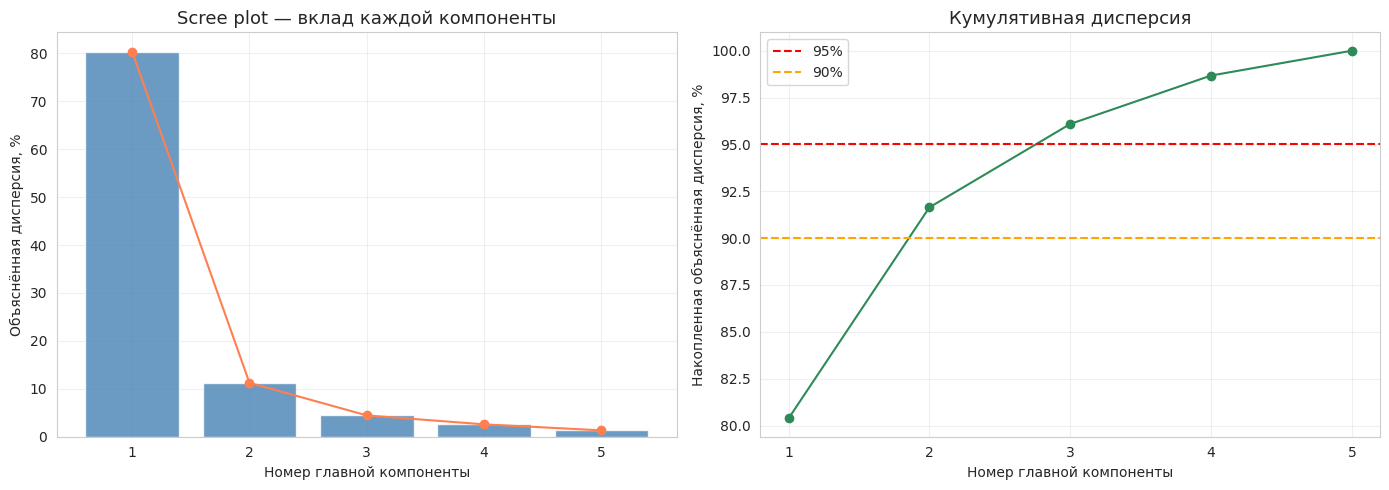

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained)+1), explained*100, color='steelblue', alpha=0.8)
axes[0].plot(range(1, len(explained)+1), explained*100, 'o-', color='coral')
axes[0].set_xlabel("Номер главной компоненты")
axes[0].set_ylabel("Объяснённая дисперсия, %")
axes[0].set_title("Scree plot — вклад каждой компоненты")
axes[0].set_xticks(range(1, len(explained)+1))
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cumulative)+1), cumulative*100, 'o-', color='seagreen')
axes[1].axhline(95, color='red', linestyle='--', label='95%')
axes[1].axhline(90, color='orange', linestyle='--', label='90%')
axes[1].set_xlabel("Номер главной компоненты")
axes[1].set_ylabel("Накопленная объяснённая дисперсия, %")
axes[1].set_title("Кумулятивная дисперсия")
axes[1].set_xticks(range(1, len(cumulative)+1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Как видно из графика, 4 параметра объясняют больше 98% информации, значит, один признак не несет существенной полезной нагрузки и его можно убрать.

### PCA с k параметрами.

Выбор количества параметров после PCA

In [122]:
n_components=2

In [126]:
n_components=3

In [130]:
n_components=4

In [131]:
from sklearn.decomposition import PCA
import pandas as pd

pca_final = PCA(n_components=n_components)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

print(f"Размерность до PCA:  {X_train_scaled.shape[1]}")
print(f"Размерность после:   {X_train_pca.shape[1]}")
print(f"Сохранено дисперсии: {pca_final.explained_variance_ratio_.sum()*100:.2f}%")

Размерность до PCA:  5
Размерность после:   4
Сохранено дисперсии: 98.67%


### Построение регриссионной модели после PCA.

In [132]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

model_lr_pca = LinearRegression()
cv_r2_lr_pca = cross_val_score(model_lr_pca, X_train_pca, y_train_log, cv=5, scoring='r2')
model_lr_pca.fit(X_train_pca, y_train_log)
y_pred_lr_pca = np.expm1(model_lr_pca.predict(X_test_pca))
y_test_orig = np.expm1(y_test_log)

rmse_lr_pca = np.sqrt(mean_squared_error(y_test_orig, y_pred_lr_pca))
r2_lr_pca   = r2_score(y_test_orig, y_pred_lr_pca)
mape_lr_pca = mean_absolute_percentage_error(y_test_orig, y_pred_lr_pca)

print("=== Linear на PCA ===")
print(f"CV R²: {cv_r2_lr_pca.mean():.4f} ± {cv_r2_lr_pca.std():.4f}")
print(f"RMSE:  {rmse_lr_pca:,.0f} руб.")
print(f"R²:    {r2_lr_pca:.4f}")
print(f"MAPE:  {mape_lr_pca*100:.2f}%")

alphas = np.logspace(-4, 2, 50)
ridge_cv_pca = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv_pca.fit(X_train_pca, y_train_log)

model_ridge_pca = Ridge(alpha=ridge_cv_pca.alpha_)
cv_r2_ridge_pca = cross_val_score(model_ridge_pca, X_train_pca, y_train_log, cv=5, scoring='r2')
model_ridge_pca.fit(X_train_pca, y_train_log)
y_pred_ridge_pca = np.expm1(model_ridge_pca.predict(X_test_pca))

rmse_ridge_pca = np.sqrt(mean_squared_error(y_test_orig, y_pred_ridge_pca))
r2_ridge_pca   = r2_score(y_test_orig, y_pred_ridge_pca)
mape_ridge_pca = mean_absolute_percentage_error(y_test_orig, y_pred_ridge_pca)

print("\n=== Ridge на PCA ===")
print(f"alpha: {ridge_cv_pca.alpha_:.4f}")
print(f"CV R²: {cv_r2_ridge_pca.mean():.4f} ± {cv_r2_ridge_pca.std():.4f}")
print(f"RMSE:  {rmse_ridge_pca:,.0f} руб.")
print(f"R²:    {r2_ridge_pca:.4f}")
print(f"MAPE:  {mape_ridge_pca*100:.2f}%")

lasso_cv_pca = LassoCV(alphas=np.logspace(-4, 1, 50), cv=5, random_state=42, max_iter=10000)
lasso_cv_pca.fit(X_train_pca, y_train_log)

model_lasso_pca = Lasso(alpha=lasso_cv_pca.alpha_, max_iter=10000)
cv_r2_lasso_pca = cross_val_score(model_lasso_pca, X_train_pca, y_train_log, cv=5, scoring='r2')
model_lasso_pca.fit(X_train_pca, y_train_log)
y_pred_lasso_pca = np.expm1(model_lasso_pca.predict(X_test_pca))

rmse_lasso_pca = np.sqrt(mean_squared_error(y_test_orig, y_pred_lasso_pca))
r2_lasso_pca   = r2_score(y_test_orig, y_pred_lasso_pca)
mape_lasso_pca = mean_absolute_percentage_error(y_test_orig, y_pred_lasso_pca)

print("\n=== Lasso на PCA ===")
print(f"alpha: {lasso_cv_pca.alpha_:.6f}")
print(f"CV R²: {cv_r2_lasso_pca.mean():.4f} ± {cv_r2_lasso_pca.std():.4f}")
print(f"RMSE:  {rmse_lasso_pca:,.0f} руб.")
print(f"R²:    {r2_lasso_pca:.4f}")
print(f"MAPE:  {mape_lasso_pca*100:.2f}%")

=== Linear на PCA ===
CV R²: 0.8345 ± 0.0075
RMSE:  254,108 руб.
R²:    0.7371
MAPE:  25.66%

=== Ridge на PCA ===
alpha: 24.4205
CV R²: 0.8345 ± 0.0076
RMSE:  254,102 руб.
R²:    0.7371
MAPE:  25.66%

=== Lasso на PCA ===
alpha: 0.006866
CV R²: 0.8347 ± 0.0078
RMSE:  254,839 руб.
R²:    0.7356
MAPE:  25.67%


## Итоговая таблица до/после PCA.

In [133]:
import pandas as pd

comparison = pd.DataFrame({
    'Модель': ['Linear', 'Ridge', 'Lasso'],
    'RMSE до PCA':    [rmse_log,      rmse_r,        rmse_l],
    'RMSE после PCA': [rmse_lr_pca,   rmse_ridge_pca, rmse_lasso_pca],
    'R² до PCA':      [r2_log,        r2_r,          r2_l],
    'R² после PCA':   [r2_lr_pca,     r2_ridge_pca,  r2_lasso_pca],
    'MAPE до PCA':    [mape_log*100,  mape_r*100,    mape_l*100],
    'MAPE после PCA': [mape_lr_pca*100, mape_ridge_pca*100, mape_lasso_pca*100]
})

styled = (comparison.style
    .format({
        'RMSE до PCA':    '{:,.0f}',
        'RMSE после PCA': '{:,.0f}',
        'R² до PCA':      '{:.4f}',
        'R² после PCA':   '{:.4f}',
        'MAPE до PCA':    '{:.2f}%',
        'MAPE после PCA': '{:.2f}%'
    })
    .set_caption("Сравнение моделей до и после PCA")
)

styled

,Модель,RMSE до PCA,RMSE после PCA,R² до PCA,R² после PCA,MAPE до PCA,MAPE после PCA
0,Linear,"255,561","254,108",0.7341,0.7371,25.59%,25.66%
1,Ridge,"255,628","254,102",0.7340,0.7371,25.58%,25.66%
2,Lasso,"255,109","254,839",0.7350,0.7356,25.62%,25.67%


# Заключение.

Перед началом выполнения лабораторной работы был изучен датасет с предсказанием цены на машину на основе ключевых признаков. Всего в датасете было 8128 строк и 12 столбцов. После удаления дубликатов и пустых значений из датасета осталось всего 6717 строк. Были удалены стобцы категориальных переменных, таким образом, осталось всего 6 столбцов - 1 целевой и 5 признаков. Была выведена корреляционная матрица и рассчитан коэффициент VIF. У поля engine значение VIF было больше 4, что означает, что мультикорреляция присутствует, и поле engine может быть объяснено через другие поля.

Подготовка данных перед обучением модели происходила в следующем порядке: строки с пустыми значениями были удалены, данные стандартизированы, выборка во всех случаях делится на train/test 70/30.

В ходе лабораторной работы было изучено построение регрессионной модели предсказания цены на автомобиль на основе заданных признаков. Были построены три разных модели: линейная, лассо и гребневая. По итогам сравнения показателей эффективности на исходных данных трех разных моделей можно сделать следующий вывод: модель Lasso имеет более высокие метрики RMSE (средняя ошибка в рублях) и R^2 (доля объясненной дисперсии), но самый низкий показатель MAPE (средний процент ошибки). Самый высокий показатель MAPE у модели линейной регрессии. Однако, говорить о качестве модели на основе этих показателей нельзя, так как разница у них незначительна (менее 0,5%), то есть, можно сделать вывод, что все модели практически одинаково эффективны.

После PCA было принято решение попробовать столбцы с разными параметрами (от 2 до 4). На количестве параметров равном 2-3 показатели эффективности модели снизились. На количестве параметров 2-3 показатель RMSE вырос на ~27%, показатель R^2 снизился на ~15%, показатель MAPE вырос на ~4%. На количестве параметров, равном 4 RMSE и R^2 немного улучшились, но, при этом, показатель MAPE также немного увеличился. Изменение сделало некоторые показатели лучше, но все равно не сильно лучше исходных (RMSE - 0,5, R^2 - 0,001, MAPE - 0,1%).

# Список использованных источников.

  1 Электронный курс "Системы искусственного интеллекта и машинное обучение" в образовательной среде НГТУ НЭТИ Dispace 3.0. Постановка задачи к лабораторной работе №1 [Электронный ресурс]. - 2025. - URL: https://dispace.nstu.ru/course/965/9020/23586 (дата обращения 16.09.2026).

  2 Платформа для соревнований по анализу данных, искусственному интеллекту и машинному обучению Kaggle. DataHub. - URL: https://www.kaggle.com/datasets (дата обращения 16.09.2026).

  3 Cloud.ru — российский провайдер облачных сервисов и AI‑технологий. Блог. Машинное обучение на Python: гайд для начинающих. - URL: https://cloud.ru/blog/mashinnoye-obucheniye-na-python (дата обращения 16.09.2026).

# Приложение.

Исходный код:

https://github.com/avelimssaa/MachineLearning